# Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    make_scorer
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
df = pd.read_csv('/content/Employee Attrition.csv')

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


# Step 2: Dataset Verification

In [ ]:
print("Dataset Verification")
print("=" * 60)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nAll Dataset Columns:")
print(df.columns.tolist())

Dataset Verification
Number of Rows: 59598
Number of Columns: 24

All Dataset Columns:
['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']


# Step 3: Feature and Target Separation

In [ ]:
X = df.drop(columns=['Employee ID', 'Attrition'])
y = df['Attrition']

print("Feature and Target Separation")
print("=" * 60)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nTarget Values:")
print(y.unique())

Feature and Target Separation
Feature Shape: (59598, 22)
Target Shape: (59598,)

Feature Columns:
['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Target Values:
['Stayed' 'Left']


# Step 4: Target Distribution

In [ ]:
print("Attrition Value Counts")
print("=" * 60)

print(y.value_counts())

print("\nAttrition Percentage")
print("=" * 60)

print(y.value_counts(normalize=True).mul(100).round(2))

Attrition Value Counts
Attrition
Stayed    31260
Left      28338
Name: count, dtype: int64

Attrition Percentage
Attrition
Stayed    52.45
Left      47.55
Name: proportion, dtype: float64


# Step 5: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Train-Test Split Completed")
print("=" * 60)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape :", X_test.shape)

print("Training Target Shape :", y_train.shape)
print("Testing Target Shape  :", y_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Train-Test Split Completed
Training Feature Shape: (47678, 22)
Testing Feature Shape : (11920, 22)
Training Target Shape : (47678,)
Testing Target Shape  : (11920,)

Training Target Distribution:
Attrition
Stayed    25008
Left      22670
Name: count, dtype: int64

Testing Target Distribution:
Attrition
Stayed    6252
Left      5668
Name: count, dtype: int64


# Step 6: Identify numerical and categorical features

In [ ]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Identify numerical and categorical features")
print("=" * 60)

print("\nNumerical Features:")
print(numerical_features)

print("\nNumber of Numerical Features:", len(numerical_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:", len(categorical_features))

Identify numerical and categorical features

Numerical Features:
['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']

Number of Numerical Features: 7

Categorical Features:
['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Number of Categorical Features: 15


# Step 7: Preprocessing Pipeline

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Random Forest Preprocessing Pipeline Created Successfully")
print("=" * 60)
print("Numerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))

Random Forest Preprocessing Pipeline Created Successfully
Numerical Features: 7
Categorical Features: 15


# Step 8: Baseline Random Forest Pipeline

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('rf', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Baseline Random Forest Pipeline Created Successfully")
print("=" * 60)
print("Model: Random Forest Classifier")
print("Number of Trees:", 100)
print("Random State:", 42)
print("Number of CPU Cores: All Available")

Baseline Random Forest Pipeline Created Successfully
Model: Random Forest Classifier
Number of Trees: 100
Random State: 42
Number of CPU Cores: All Available


# Step 9: Train Baseline Random Forest

In [ ]:
rf_pipeline.fit(X_train, y_train)

print("Baseline Random Forest Model Trained Successfully")
print("=" * 60)

Baseline Random Forest Model Trained Successfully


# Step 10: Baseline Predictions

In [ ]:
y_pred_rf = rf_pipeline.predict(X_test)

print("Baseline Random Forest Predictions Generated Successfully")
print("=" * 60)

print("Number of Predictions:", len(y_pred_rf))
print("First 20 Predictions:")
print(y_pred_rf[:20])

Baseline Random Forest Predictions Generated Successfully
Number of Predictions: 11920
First 20 Predictions:
['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Left' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Stayed']


# Step 11: Model Evaluation Baseline Performance

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label='Left')
recall_rf = recall_score(y_test, y_pred_rf, pos_label='Left')
f1_rf = f1_score(y_test, y_pred_rf, pos_label='Left')

print("Baseline Random Forest Performance")
print("=" * 50)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

Baseline Random Forest Performance
Accuracy : 0.7450
Precision: 0.7296
Recall   : 0.7366
F1 Score : 0.7331


# Step 12: Confusion Matrix

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf,
    labels=['Stayed', 'Left']
)

print("Baseline Random Forest Confusion Matrix")
print("=" * 60)

print(cm_rf)

print("\nTotal samples in confusion matrix:", cm_rf.sum())

Baseline Random Forest Confusion Matrix
[[4705 1547]
 [1493 4175]]

Total samples in confusion matrix: 11920


# Step 13: Classification Report

In [ ]:
print("Classification Report - Baseline Random Forest")
print("=" * 60)

print(
    classification_report(y_test, y_pred_rf,
        labels=['Stayed', 'Left']
    )
)

Classification Report - Baseline Random Forest
              precision    recall  f1-score   support

      Stayed       0.76      0.75      0.76      6252
        Left       0.73      0.74      0.73      5668

    accuracy                           0.74     11920
   macro avg       0.74      0.74      0.74     11920
weighted avg       0.75      0.74      0.75     11920



# Step 14: Baseline ROC-AUC

In [ ]:
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Baseline Random Forest ROC-AUC")
print("=" * 50)

print(f"ROC-AUC : {roc_auc_rf:.4f}")

Baseline Random Forest ROC-AUC
ROC-AUC : 0.8316


# Step 15: Hyperparameter Grid

In [ ]:
param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2]
}

print("Random Forest Parameter Grid")
print("=" * 60)

print(param_grid_rf)

Random Forest Parameter Grid
{'rf__n_estimators': [100, 200], 'rf__max_depth': [None, 10, 20], 'rf__min_samples_split': [2, 5], 'rf__min_samples_leaf': [1, 2]}


# Step 16: Hyperparameter Tuning

In [ ]:
f1_left_scorer = make_scorer(
    f1_score,
    pos_label = 'Left'
)

grid_rf = GridSearchCV(
    estimator = rf_pipeline,
    param_grid = param_grid_rf,
    cv = 3,
    scoring = f1_left_scorer,
    n_jobs = -1,
    verbose = 1
)

grid_rf.fit(X_train, y_train)

print("Random Forest Hyperparameter Tuning Completed")
print("=" * 60)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_rf.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Random Forest Hyperparameter Tuning Completed
Best Parameters:
{'rf__max_depth': 10, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}

Best Cross-Validation F1 Score:
0.7345


# Step 17: Tuned Model

In [ ]:
tuned_rf_pipeline = grid_rf.best_estimator_

print("Tuned Random Forest Model Ready")
print("=" * 60)

print("Best Parameters:")
print(grid_rf.best_params_)

Tuned Random Forest Model Ready
Best Parameters:
{'rf__max_depth': 10, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}


# Step 18: Tuned Predictions

In [ ]:
y_pred_tuned_rf = tuned_rf_pipeline.predict(X_test)

print("Tuned Random Forest Predictions Generated Successfully")
print("=" * 60)

print("Number of Predictions:", len(y_pred_tuned_rf))

print("First 20 Predictions:")
print(y_pred_tuned_rf[:20])

Tuned Random Forest Predictions Generated Successfully
Number of Predictions: 11920
First 20 Predictions:
['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Stayed']


# Step 19: Tuned Model Evaluation Performance

In [ ]:
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf, pos_label='Left')
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf, pos_label='Left')
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf, pos_label='Left')

print("Tuned Random Forest Performance")
print("=" * 50)

print(f"Accuracy : {accuracy_tuned_rf:.4f}")
print(f"Precision: {precision_tuned_rf:.4f}")
print(f"Recall   : {recall_tuned_rf:.4f}")
print(f"F1 Score : {f1_tuned_rf:.4f}")

Tuned Random Forest Performance
Accuracy : 0.7481
Precision: 0.7380
Recall   : 0.7290
F1 Score : 0.7335


# Step 20: Tuned Confusion Matrix

In [ ]:
cm_tuned_rf = confusion_matrix(
    y_test,
    y_pred_tuned_rf,
    labels=['Stayed', 'Left']
)

print("Tuned Random Forest Confusion Matrix")
print("=" * 60)
print(cm_tuned_rf)
print("\nTotal samples in confusion matrix:", cm_tuned_rf.sum())

Tuned Random Forest Confusion Matrix
[[4785 1467]
 [1536 4132]]

Total samples in confusion matrix: 11920


# Step 21: Tuned Classification Report

In [ ]:
print("Classification Report - Tuned Random Forest")
print("=" * 60)
print(
    classification_report(y_test, y_pred_tuned_rf,
        labels=['Stayed', 'Left']
    )
)

Classification Report - Tuned Random Forest
              precision    recall  f1-score   support

      Stayed       0.76      0.77      0.76      6252
        Left       0.74      0.73      0.73      5668

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



# Step 22: Tuned ROC-AUC

In [ ]:
y_prob_tuned_rf = tuned_rf_pipeline.predict_proba(X_test)[:, 1]

roc_auc_tuned_rf = roc_auc_score(y_test, y_prob_tuned_rf)

print("Tuned Random Forest ROC-AUC")
print("=" * 50)
print(f"ROC-AUC : {roc_auc_tuned_rf:.4f}")

Tuned Random Forest ROC-AUC
ROC-AUC : 0.8368


# Step 23: Feature Importance

Now we can identify which features contributed most to the tuned Random Forest's decisions.

Because we used OneHotEncoder, the original categorical columns have been converted into multiple encoded features. We'll extract those feature names and match them with the Random Forest importance values.

In [ ]:
# Get the trained Random Forest model
rf_model = tuned_rf_pipeline.named_steps['rf']

# Get the preprocessing step
preprocessor_rf = tuned_rf_pipeline.named_steps['preprocessor']

# Get transformed feature names
feature_names_rf = preprocessor_rf.get_feature_names_out()

# Get feature importance values
importance_rf = rf_model.feature_importances_

# Create DataFrame
feature_importance_rf = pd.DataFrame({
    'Feature': feature_names_rf,
    'Importance': importance_rf
})

# Sort by importance
feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

print("Random Forest Feature Importance")
print("=" * 60)

print("\nTop 15 Random Forest Features:")
print("=" * 60)

print(
    feature_importance_rf.head(15).to_string(index=False)
)

Random Forest Feature Importance

Top 15 Random Forest Features:
                         Feature  Importance
      cat__Marital Status_Single    0.144165
           cat__Job Level_Senior    0.129203
            cat__Job Level_Entry    0.105890
            cat__Remote Work_Yes    0.069702
             cat__Remote Work_No    0.065844
     cat__Marital Status_Married    0.061909
         num__Distance from Home    0.032691
       num__Number of Promotions    0.031280
     cat__Work-Life Balance_Fair    0.029909
              cat__Job Level_Mid    0.029098
       num__Number of Dependents    0.022983
           num__Years at Company    0.021295
     cat__Work-Life Balance_Poor    0.019205
cat__Work-Life Balance_Excellent    0.018240
     cat__Work-Life Balance_Good    0.017706


# Step 24: Feature Importance Visualization

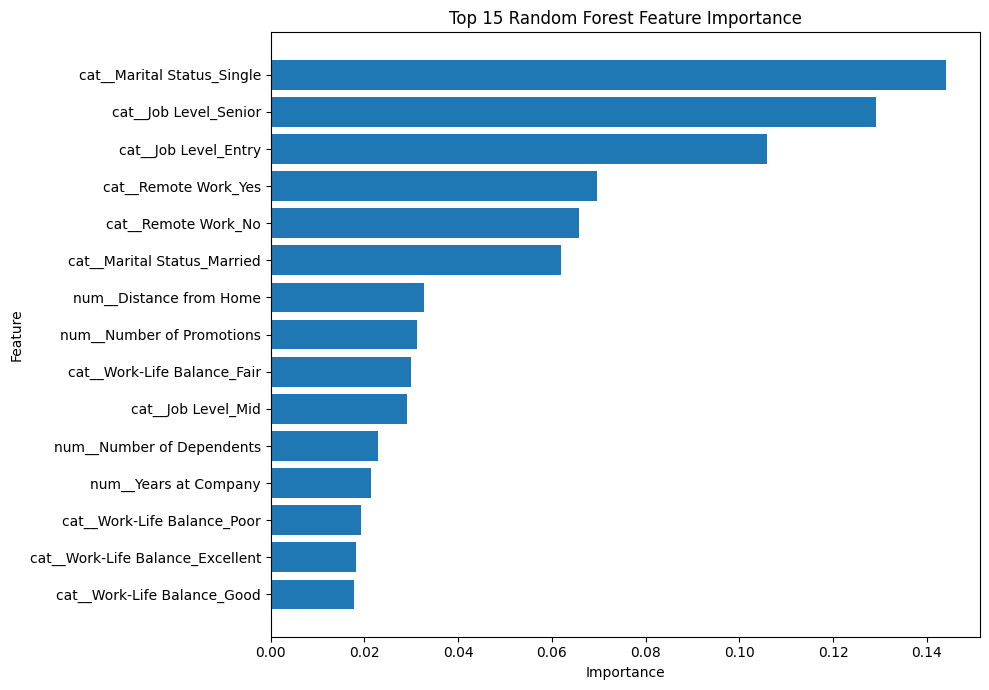

In [ ]:
top_15_rf = feature_importance_rf.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_15_rf['Feature'],
    top_15_rf['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Random Forest Feature Importance')
plt.tight_layout()
plt.show()

# Step 25: Baseline vs Tuned Comparison


In [ ]:
comparison_rf = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision (Left)',
        'Recall (Left)',
        'F1 Score (Left)',
        'ROC-AUC'
    ],
    'Baseline': [
        0.7450,
        0.7296,
        0.7366,
        0.7331,
        0.8316
    ],
    'Tuned': [
        0.7481,
        0.7380,
        0.7290,
        0.7335,
        0.8368
    ]
})

print("Baseline vs Tuned Random Forest")
print("=" * 70)
print(comparison_rf.to_string(index=False))

Baseline vs Tuned Random Forest
          Metric  Baseline  Tuned
        Accuracy    0.7450 0.7481
Precision (Left)    0.7296 0.7380
   Recall (Left)    0.7366 0.7290
 F1 Score (Left)    0.7331 0.7335
         ROC-AUC    0.8316 0.8368


# Step 26: Save Tuned Model

In [ ]:
import joblib

model_filename = "Employee_Attrition_Random_Forest_Model.pkl"
joblib.dump(
    tuned_rf_pipeline,
    model_filename
)

print("Random Forest Model Saved Successfully")
print("=" * 60)
print(f"File Name: {model_filename}")

Random Forest Model Saved Successfully
File Name: Employee_Attrition_Random_Forest_Model.pkl


# Step 27: Load Saved Model

In [ ]:
import joblib

model_filename = "Employee_Attrition_Random_Forest_Model.pkl"

loaded_rf_model = joblib.load(model_filename)

print("Random Forest Model Loaded Successfully")
print("=" * 60)
print(f"Loaded Model: {model_filename}")

Random Forest Model Loaded Successfully
Loaded Model: Employee_Attrition_Random_Forest_Model.pkl


# Step 28: Compare Original vs Loaded Model Predictions

In [ ]:
y_pred_loaded_rf = loaded_rf_model.predict(X_test)

print("Loaded Random Forest Predictions Generated Successfully")
print("=" * 60)

print("Number of Predictions:", len(y_pred_loaded_rf))

print("\nFirst 20 Predictions:")
print(y_pred_loaded_rf[:20])

Loaded Random Forest Predictions Generated Successfully
Number of Predictions: 11920

First 20 Predictions:
['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Stayed']


# Step 29: Verify the loaded model

In [ ]:
same_predictions_rf = np.array_equal(
    y_pred_tuned_rf,
    y_pred_loaded_rf
)

print("Loaded Random Forest Model Verification")
print("=" * 60)

print("Number of Predictions:", len(y_pred_loaded_rf))

print("\nFirst 20 Predictions:")
print(y_pred_loaded_rf[:20])

print("\nPrediction Comparison")
print("=" * 60)

if same_predictions_rf:
    print("Tuned and Loaded Model Predictions: SAME")
    print("Model Verification: PASSED")
else:
    print("Tuned and Loaded Model Predictions: DIFFERENT")
    print("Model Verification: FAILED")

Loaded Random Forest Model Verification
Number of Predictions: 11920

First 20 Predictions:
['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Stayed']

Prediction Comparison
Tuned and Loaded Model Predictions: SAME
Model Verification: PASSED


# Step 30: New Employee Data

In [ ]:
new_employee = pd.DataFrame({
    'Age': [30],
    'Gender': ['Male'],
    'Years at Company': [5],
    'Job Role': ['Technology'],
    'Monthly Income': [6000],
    'Work-Life Balance': ['Good'],
    'Job Satisfaction': ['High'],
    'Performance Rating': ['High'],
    'Number of Promotions': [1],
    'Overtime': ['No'],
    'Distance from Home': [10],
    'Education Level': ['Bachelor'],
    'Marital Status': ['Married'],
    'Number of Dependents': [2],
    'Job Level': ['Mid'],
    'Company Size': ['Medium'],
    'Company Tenure': [5],
    'Remote Work': ['Yes'],
    'Leadership Opportunities': ['Yes'],
    'Innovation Opportunities': ['Yes'],
    'Company Reputation': ['Good'],
    'Employee Recognition': ['High']
})

print("New Employee Data")
print("=" * 60)

print(new_employee)

New Employee Data
   Age Gender  Years at Company    Job Role  Monthly Income Work-Life Balance  \
0   30   Male                 5  Technology            6000              Good   

  Job Satisfaction Performance Rating  Number of Promotions Overtime  ...  \
0             High               High                     1       No  ...   

   Marital Status Number of Dependents Job Level  Company Size Company Tenure  \
0         Married                    2       Mid        Medium              5   

  Remote Work  Leadership Opportunities Innovation Opportunities  \
0         Yes                       Yes                      Yes   

  Company Reputation Employee Recognition  
0               Good                 High  

[1 rows x 22 columns]


# Step 30: New Employee Prediction

In [ ]:
new_employee_prediction = loaded_rf_model.predict(
    new_employee
)

print("New Employee Attrition Prediction")
print("=" * 60)

print("Prediction:", new_employee_prediction[0])

New Employee Attrition Prediction
Prediction: Stayed


# Step 31: Prediction Probabilities

In [ ]:
prediction_probabilities = loaded_rf_model.predict_proba(new_employee)[0]

model_classes = loaded_rf_model.named_steps['rf'].classes_

print("Detailed Prediction Probabilities")
print("=" * 60)

for class_name, probability in zip(
    model_classes,
    prediction_probabilities
):
    print(f"{class_name}: {probability:.6f}")
    print(f"{class_name}: {probability * 100:.2f}%")

Detailed Prediction Probabilities
Left: 0.059627
Left: 5.96%
Stayed: 0.940373
Stayed: 94.04%
